# Markov Chain Simulation vs Theory
Compare matrix method with simulation and observe convergence.

## 1. Theoretical Steady-State

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
import os

In [2]:
os.makedirs("plots", exist_ok=True)

In [3]:
plt.tight_layout()

<Figure size 640x480 with 0 Axes>

In [4]:
plot_counter = 1

In [5]:
def save_plot(name):
    global plot_counter
    filename = f"plots/{plot_counter:02d}_{name}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"Saved: {filename}")
    plot_counter += 1

In [6]:
P = np.array([[0.5,0.4,0.1],
              [0.3,0.4,0.3],
              [0.1,0.2,0.7]])

a = np.array([0.3,0.4,0.3])
k = 30

## 2. Simulation vs Theory

In [7]:
theoretical = a @ np.linalg.matrix_power(P, k)
print("Matrix method:", theoretical)

Matrix method: [0.27272727 0.31818182 0.40909091]


In [8]:
def simulate(P,state,steps):
    for _ in range(steps):
        state = random.choices([0,1,2], weights=P[state])[0]
    return state

runs = 10000
counts = np.zeros(3)

for _ in range(runs):
    s = random.choices([0,1,2], weights=a)[0]
    final = simulate(P,s,30)
    counts[final] += 1

print("Simulation:", counts/runs)

Simulation: [0.2648 0.319  0.4162]


In [9]:
# Solve steady-state directly
A = P.T - np.eye(3)
A = np.vstack([A, np.ones(3)])
b = np.array([0, 0, 0, 1])

pi_steady = np.linalg.lstsq(A, b, rcond=None)[0]

print("Steady-state solve:", pi_steady)

Steady-state solve: [0.27272727 0.31818182 0.40909091]


## 3. Convergence Behavior

Saved: plots/01_convergence_main.png


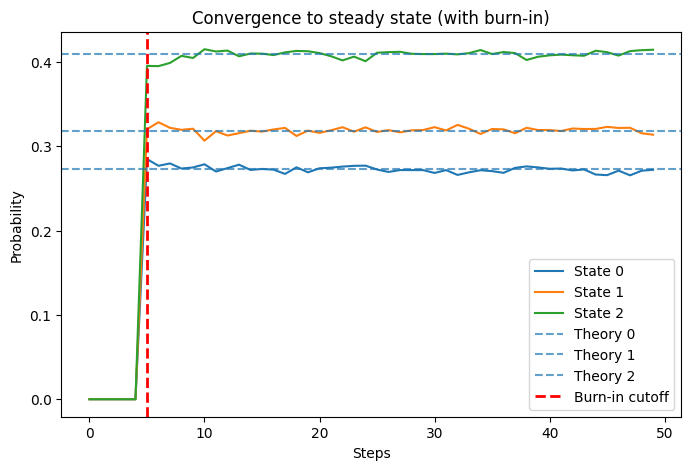

In [10]:
steps = 50
runs = 20000
burn_in = 5   # NEW: ignore early bias

history = np.zeros((steps, 3))

for _ in range(runs):
    s = 0   # OPTIONAL: force starting state (to show bias)
    for i in range(steps):
        s = random.choices([0,1,2], weights=P[s])[0]
        
        # Only record after burn-in
        if i >= burn_in:
            history[i][s] += 1

history /= runs

# Plot results
plt.figure(figsize=(8,5))
plt.plot(history)

# Add theoretical lines
plt.axhline(y=theoretical[0], linestyle='--', alpha=0.7)
plt.axhline(y=theoretical[1], linestyle='--', alpha=0.7)
plt.axhline(y=theoretical[2], linestyle='--', alpha=0.7)
plt.axvline(x=burn_in, color='red', linestyle='--', linewidth=2)

plt.title('Convergence to steady state (with burn-in)')
plt.xlabel('Steps')
plt.ylabel('Probability')

plt.legend([
    'State 0','State 1','State 2',
    'Theory 0','Theory 1','Theory 2',
    'Burn-in cutoff'
])

save_plot("convergence_main")

plt.show()

```Shows convergence from transient behavior to steady-state after burn-in.```

The vertical dashed line indicates the burn-in period, during which the system is influenced by the initial conditions. After this point, the state probabilities stabilize and fluctuate around the steady-state values.

## 4. Zoomed Steady-State Behavior

Saved: plots/02_convergence_zoom.png


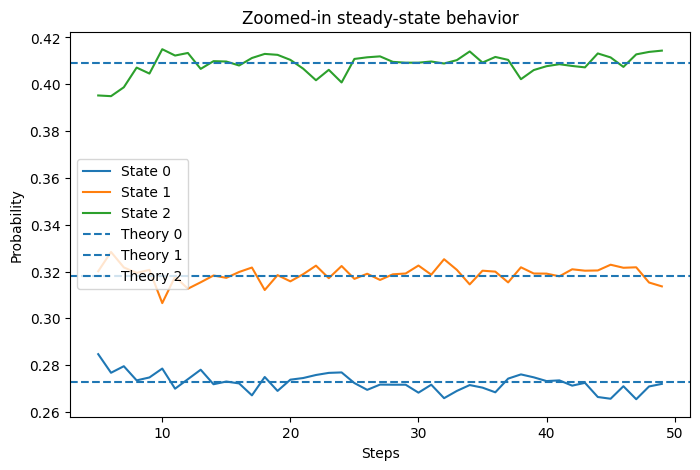

In [11]:
# Define zoom region (after burn-in)
zoom_start = burn_in
zoom_history = history[zoom_start:]

plt.figure(figsize=(8,5))

plt.plot(range(zoom_start, steps), zoom_history)

# Theoretical lines
plt.axhline(y=theoretical[0], linestyle='--')
plt.axhline(y=theoretical[1], linestyle='--')
plt.axhline(y=theoretical[2], linestyle='--')

plt.title('Zoomed-in steady-state behavior')
plt.xlabel('Steps')
plt.ylabel('Probability')

plt.legend([
    'State 0','State 1','State 2',
    'Theory 0','Theory 1','Theory 2'
])

save_plot("convergence_zoom")

plt.show()

```Illustrates small stochastic fluctuations around steady-state.```

The zoomed-in view highlights that after the burn-in period, the deviations from the steady-state are small and fluctuate due to randomness. This confirms that the system has reached equilibrium, and the remaining variability is due to stochastic effects rather than systematic change.

## 5. Effect of Initial State

Saved: plots/03_initial_state_effect.png


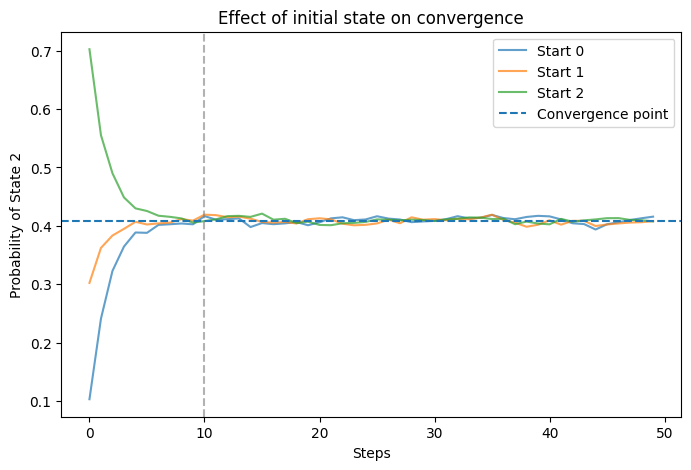

In [12]:
steps = 50
runs = 10000

colors = ['blue', 'orange', 'green']

plt.figure(figsize=(8,5))

for start_state in [0, 1, 2]:

    history = np.zeros((steps, 3))
    
    for _ in range(runs):
        s = start_state   # FIXED starting state
        
        for i in range(steps):
            s = random.choices([0,1,2], weights=P[s])[0]
            history[i][s] += 1

    history /= runs

    # Plot only one state for clarity (e.g. State 2)
    plt.plot(history[:,2], label=f"Start {start_state}", alpha=0.7)

plt.axhline(y=theoretical[2], linestyle='--')
plt.axvline(x=10, color='gray', linestyle='--', alpha=0.6)

plt.title("Effect of initial state on convergence")
plt.xlabel("Steps")
plt.ylabel("Probability of State 2")

plt.legend(['Start 0','Start 1','Start 2','Convergence point'])

save_plot("initial_state_effect")

plt.show()

```Different starting states converge to the same steady-state distribution.```

The results show that different initial states lead to different short-term behavior, but all trajectories converge to the same steady-state value. This demonstrates that the long-run distribution of the Markov chain is independent of its initial condition. The differences observed in the early steps represent transient effects, while convergence occurs rapidly within a few iterations.

Saved: plots/04_initial_state_zoom.png


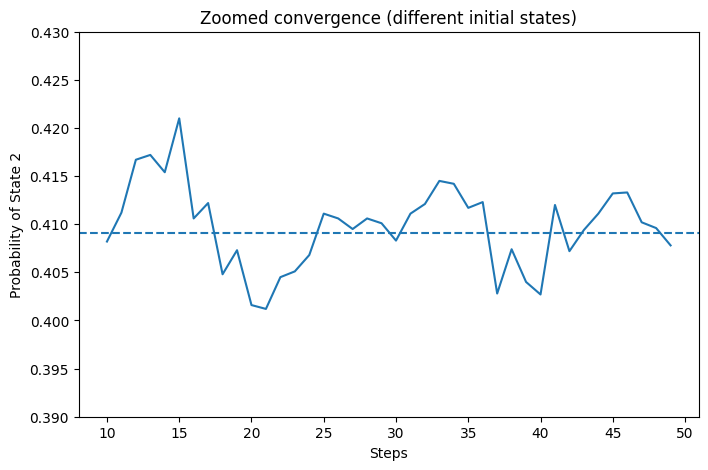

In [13]:
zoom_start = 10
zoom = history[:, 2]   # or reuse your tracking per start

plt.figure(figsize=(8,5))

# simpler approach (reuse last run data if not saved separately)
plt.plot(range(zoom_start, steps), history[zoom_start:, 2])

plt.axhline(y=theoretical[2], linestyle='--')

plt.title('Zoomed convergence (different initial states)')
plt.xlabel('Steps')
plt.ylabel('Probability of State 2')

plt.ylim([0.39, 0.43])  # tighten view

save_plot("initial_state_zoom")

plt.show()

The results show that despite starting from different initial states, all trajectories converge to the same steady-state probability. This confirms that the long-run behavior of the Markov chain is independent of the initial condition, which is a key property of ergodic systems.

## 6. Conclusion

The simulation results show that although the state probabilities fluctuate due to randomness, they stabilize around fixed values that match the theoretical steady-state distribution. This illustrates that a Markov chain “forgets” its initial state over time and converges to a unique equilibrium distribution. The small oscillations observed in the plot are due to inherent randomness in the simulation, but the long-run behavior aligns closely with the analytical results. This demonstrates both the predictive power of the theoretical model and the validity of simulation as a tool to approximate long-run system behavior.